# File to run experiments with various hyperparameters

In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print(datetime.datetime.now())


Initializing package . . . 😘
2025-03-18 00:19:23.558167


# Prepare Data

In [2]:
def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] + 1440 >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct,
            'lower_1' : vals.quantile(0.01),
            'upper_1' : vals.quantile(0.99),
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

def find_aki_onset_for_patient(patient_df, creat_itemids):
    """
    환자 한 명(patient_df)에 대해
    - 크레아티닌(itemid ∈ creat_itemids)만 필터
    - offset 오름차순으로 보면서 AKI 기준을 만족하는 모든 시점을 리스트로 반환
      AKI 기준:
        (A) 최근 48시간(=2880분) 내의 측정치들과 비교하여, 
            현재 값과의 차이가 >= 0.3 mg/dL인 경우
        (B) 전체 측정치의 baseline(최소 creatinine) 대비 1.5배 이상 증가한 경우
    반환: 리스트 (예: [off1, off2, ...]), 조건을 만족하는 시점이 없으면 빈 리스트 []
    """
    # 1) 해당 환자의 크레아티닌 값만 필터
    cdf = patient_df[patient_df['itemid'].isin(creat_itemids)].copy()
    if cdf.empty:
        return []
    # 2) baseline = 전체 측정치 중 최소값
    baseline = cdf['value'].min()
    # 3) 시간 순 정렬
    cdf = cdf.sort_values('offset').reset_index(drop=True)
    recent_measure = []  # 최근 48시간 내 측정 (offset, value)
    onsets = []
    for i, row in cdf.iterrows():
        off = row['offset']
        val = row['value']
        # 최근 48시간 내 측정을 유지 (off-2880분 이후)
        lower_bound = off - 2880
        recent_measure = [(poff, pval) for (poff, pval) in recent_measure if poff >= lower_bound]
        recent_measure.append((off, val))
        # Criterion (B): baseline 대비 1.5배 이상
        if val >= 1.5 * baseline:
            onsets.append(off)
            continue  # 추가 onset 검사를 위해 계속 진행
        # Criterion (A): 최근 48시간 내 어느 측정과 비교해도 val - prev_val >= 0.3
        for (prev_off, prev_val) in recent_measure:
            if val - prev_val >= 0.3:
                onsets.append(off)
                break
    if onsets == []:
        onsets = np.nan
    return onsets


def build_aki_outcome(train_df, valid_df, test_df,
                      creat_itemids, trim_percentile=0.01):
    """
    - data: [hadm_id, offset, itemid, value]
    - creat_itemids: creatinine에 해당하는 itemid 집합
    - trim_percentile: 상하위 X% outlier 제거 (train 기준)

    반환:
      outcome_train, outcome_valid, outcome_test
      => [hadm_id, aki_offset], aki_offset=NaN이면 AKI 없음
    """
    # 0) creatinine itemid만 필터
    #    (다른 변수 필요 없다고 가정)
    print(f'[AKI Outcomes] 🪄 Starting process at {datetime.datetime.now()}...')

    orig_train_ids = train_df['hadm_id'].unique()
    orig_valid_ids = valid_df['hadm_id'].unique()
    orig_test_ids  = test_df['hadm_id'].unique()

    train_df = train_df[train_df['itemid'].isin([creat_itemids])].copy()
    valid_df = valid_df[valid_df['itemid'].isin([creat_itemids])].copy()
    test_df  = test_df[test_df['itemid'].isin([creat_itemids])].copy()

    # 1) binary item detect? 여기서는 크레아티닌이라 이진은 아님 -> pass
    #    (사용자가 필요하면 추가)
    # 2) trim outliers
    if trim_percentile is not None and trim_percentile > 0:
        clip_bounds = {}
        # (a) Train set으로부터 각 itemid별 상하위 cut 구하기
        for item_id, group in train_df.groupby('itemid'):


            lower = group['value'].quantile(trim_percentile)
            upper = group['value'].quantile(1 - trim_percentile)
            clip_bounds[item_id] = (lower, upper)

        # (b) Train, Valid, Test에서 실제로 제거
        def trim_df(df, clip_dict):
            new_list = []
            for _item_id, group in df.groupby('itemid'):
                if _item_id in clip_dict:
                    l, u = clip_dict[_item_id]
                    clipped = group.loc[(group['value'] >= l) & (group['value'] <= u)]
                    new_list.append(clipped)
                else:
                    # clip_dict에 없는 itemid (train에 드물거나 없었을 수 있음)
                    # 그대로 두거나, 스킵하는 등 정책 결정
                    new_list.append(group)

            if len(new_list) > 0:
                return pd.concat(new_list, ignore_index=True)
            else:
                return pd.DataFrame(columns=df.columns)

        train_df = trim_df(train_df, clip_bounds)
        valid_df = trim_df(valid_df, clip_bounds)
        test_df  = trim_df(test_df, clip_bounds)

        print(f"[Trimming] Completed. Remaining train size = {len(train_df)}, "
              f"valid size = {len(valid_df)}, test size = {len(test_df)}")
    else:
        print("[Trimming] Skipped or trim_percentile=0")

    # 3) hadm_id별 aki onset
    #    train
    train_results=[]
    for hadm_id, group in train_df.groupby('hadm_id'):
        onset = find_aki_onset_for_patient(group, [creat_itemids])
        train_results.append((hadm_id, onset))
    outcome_train = pd.DataFrame(train_results, columns=['hadm_id','aki_offset'])
    print(f"   ✅ [Train] AKI onsets in {outcome_train.dropna(subset=['aki_offset'])['hadm_id'].nunique()} ids")

    #    valid
    valid_results=[]
    for hadm_id, group in valid_df.groupby('hadm_id'):
        onset = find_aki_onset_for_patient(group, [creat_itemids])
        valid_results.append((hadm_id, onset))
    outcome_valid = pd.DataFrame(valid_results, columns=['hadm_id','aki_offset'])
    print(f"   ✅ [Valid] AKI onsets in {outcome_valid.dropna(subset=['aki_offset'])['hadm_id'].nunique()} ids")

    #    test
    test_results=[]
    for hadm_id, group in test_df.groupby('hadm_id'):
        onset = find_aki_onset_for_patient(group, [creat_itemids])
        test_results.append((hadm_id, onset))
    outcome_test = pd.DataFrame(test_results, columns=['hadm_id','aki_offset'])
    print(f"   ✅ [Test] AKI onsets in {outcome_test.dropna(subset=['aki_offset'])['hadm_id'].nunique()} ids")

    # 1) 각 outcome_df에 'set' 열을 추가하여 구분
    outcome_train['set'] = 'Train'
    outcome_valid['set'] = 'Valid'
    outcome_test['set'] = 'Test'


    print(f'[AKI Outcomes] 🪄 Process over at {datetime.datetime.now()}...')


    return outcome_train, outcome_valid, outcome_test

def mask_rows_by_proportion(df: pd.DataFrame, mask_ratio: float, seed: int = 42) -> pd.DataFrame:
    """
    주어진 DataFrame (컬럼: ['offset', 'hadm_id', 'itemid', 'value'])에 대해,
    각 hadm_id별로 전체 관측치 중 일정 비율(mask_ratio)을 무작위로 masking 처리합니다.
    (mask_ratio 예: 0.3이면 각 hadm_id 그룹의 30% 행의 value를 NaN으로 설정)
    
    Parameters:
      df: DataFrame with columns ['offset', 'hadm_id', 'itemid', 'value']
      mask_ratio: masking할 비율 (예: 0.3)
      seed: 재현성을 위한 난수 시드
      
    Returns:
      df_masked: 원본 DataFrame과 동일한 구조이며, 각 hadm_id별로 mask_ratio에 해당하는 행의 'value'가 NaN 처리됨.
    """
    df_masked = df.copy()
    np.random.seed(seed)
    
    # 각 hadm_id 그룹별로 처리
    for hadm_id, group in df_masked.groupby('hadm_id'):
        idxs = group.index
        n_rows = len(idxs)
        n_to_mask = int(np.floor(n_rows * mask_ratio))
        if n_to_mask > 0:
            mask_idxs = np.random.choice(idxs, size=n_to_mask, replace=False)
            df_masked.loc[mask_idxs, 'value'] = np.nan
            
    return df_masked

### All vars

In [3]:
data_static = pd.read_feather('eicu_data_static.feather').rename(columns={'patientunitstayid' : 'hadm_id'})
eicu_ids = data_static['hadm_id'].unique()

data_vital = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_lab = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_treatment = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()

data = pd.concat([
    data_vital, 
    data_lab, 
    data_treatment
    ])


# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds_24_eicu.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

# (2) scaler_dict
with open('scaler_dict_24_eicu.pkl', 'rb') as f:
    scaler_dict_all = pickle.load(f)

# item_dict_total을 사용하여 원래의 itemid 값을 매핑합니다.
# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

emb_idx_total = len(item_dict_total)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(eicu_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(eicu_ids) * 0.6)
valid_size = int(len(eicu_ids) * 0.8)
train_hadm_ids = eicu_ids[:train_size]
valid_hadm_ids = eicu_ids[train_size:valid_size]
test_hadm_ids = eicu_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

creat_itemids = item_dict_total['creatinine']



# (D) 최종 DF - aki가 있는 stay만 or 전체 stay


train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

train_outcome_df, valid_outcome_df, test_outcome_df = build_aki_outcome(train_df, valid_df, test_df, creat_itemids=creat_itemids)

#--------------------------
# Only stays with aki
#--------------------------
train_outcome_df = train_outcome_df.dropna().reset_index(drop=True)
valid_outcome_df = valid_outcome_df.dropna().reset_index(drop=True)
test_outcome_df = test_outcome_df.dropna().reset_index(drop=True)

train_outcome_df.to_feather('./model_results/train_aki_outcome_mask_trained_on_eicu.feather')
valid_outcome_df.to_feather('./model_results/valid_aki_outcome_mask_trained_on_eicu.feather')
test_outcome_df.to_feather('./model_results/test_aki_outcome_mask_trained_on_eicu.feather')

train_final_ids = train_outcome_df['hadm_id'].unique()
valid_final_ids = valid_outcome_df['hadm_id'].unique()
test_final_ids = test_outcome_df['hadm_id'].unique()


#--------------------------
#--------------------------
# data_vital, data_lab, data_treatment 각각에 대해 masking 적용 가능
data_vital = mask_rows_by_proportion(data_vital, mask_ratio=0.15, seed=9871)
# data_lab = mask_rows_by_proportion(data_lab, mask_ratio=0.3, seed=42)
# data_treatment = mask_rows_by_proportion(data_treatment, mask_ratio=0.3, seed=42)

data = pd.concat([
    data_vital, 
    data_lab, 
    data_treatment
    ])

# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna()

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
#--------------------------
#--------------------------

print(datetime.datetime.now())

loader_maker = strats.MakeLoadersAKI(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=32, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=8*60, emb_idx=emb_idx_total)



scaler_dict, clip_bounds, train_loader, valid_loader, test_loader, emb_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)


print(datetime.datetime.now())

[AKI Outcomes] 🪄 Starting process at 2025-03-18 00:21:43.970291...
[Trimming] Completed. Remaining train size = 368237, valid size = 122160, test size = 124032
   ✅ [Train] AKI onsets in 25874 ids
   ✅ [Valid] AKI onsets in 8592 ids
   ✅ [Test] AKI onsets in 8551 ids
[AKI Outcomes] 🪄 Process over at 2025-03-18 00:22:38.077921...
2025-03-18 00:23:45.623680
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 14 binary itemids => {32.0, 33.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 27.0, 28.0, 29.0, 30.0, 31.0}
[Trim] Trimming: percentile=0.01
  trimmed => train=37130302, valid=12072784, test=12406660
  [train] hadm_id row count => mean=1435.04, std=1835.45, min=13, max=127405, median=901.0
  [valid] hadm_id row count => mean=1405.12, std=1575.18, min=10, max=30790, median=878.0
  [test] hadm_id row count => mean=1450.90, std=1636.53, min=10, max=27629, median=915.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersAKI] Creating acute kidney in

In [4]:
data = data_vital

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


loader_maker = strats.MakeLoadersAKI(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total)

scaler_vital_dict, clip_vital_bounds, train_vital_loader, valid_vital_loader, test_vital_loader, emb_vital_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)



print(datetime.datetime.now())

print('[Finished] Vital samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 0 binary itemids => set()
[Trim] Trimming: percentile=0.01
  trimmed => train=32975401, valid=10707895, test=11018906
  [train] hadm_id row count => mean=1274.95, std=1669.13, min=1, max=123774, median=801.0
  [valid] hadm_id row count => mean=1246.70, std=1397.04, min=1, max=28478, median=776.0
  [test] hadm_id row count => mean=1288.91, std=1455.61, min=1, max=25732, median=810.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersAKI] Creating acute kidney injury datasets ...
[TimeSeriesDatasetAKI_Outcome] Total 23676 stays used
[TimeSeriesDatasetAKI_Outcome] Created 193487 samples. AKI=1: 12019
[TimeSeriesDatasetAKI_Outcome] Sequence length stats: mean=236.95, std=26.34, min=1, max=493, median=242.0
[TimeSeriesDatasetAKI_Outcome] Total 7855 stays used
[TimeSeriesDatasetAKI_Outcome] Created 62892 samples. AKI=1: 3802
[TimeSeriesDatasetAKI_Outcome] Sequence length stats: mean=237.72, std=22.5

In [5]:
data = data_lab

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

loader_maker = strats.MakeLoadersAKI(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total)

scaler_lab_dict, clip_lab_bounds, train_lab_loader, valid_lab_loader, test_lab_loader, emb_lab_idx = loader_maker.run_all(scalers_dict=scaler_dict_all, clip_bounds=clip_bounds_all)


print(datetime.datetime.now())
print('[Finished] Lab samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 0 binary itemids => set()
[Trim] Trimming: percentile=0.01
  trimmed => train=2388523, valid=791200, test=801072
  [train] hadm_id row count => mean=92.31, std=122.39, min=4, max=4165, median=54.0
  [valid] hadm_id row count => mean=92.09, std=118.65, min=4, max=2050, median=55.0
  [test] hadm_id row count => mean=93.68, std=124.74, min=3, max=2431, median=56.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersAKI] Creating acute kidney injury datasets ...
[TimeSeriesDatasetAKI_Outcome] Total 23123 stays used
[TimeSeriesDatasetAKI_Outcome] Created 184737 samples. AKI=1: 11261
[TimeSeriesDatasetAKI_Outcome] Sequence length stats: mean=14.55, std=10.48, min=1, max=91, median=11.0
[TimeSeriesDatasetAKI_Outcome] Total 7650 stays used
[TimeSeriesDatasetAKI_Outcome] Created 60676 samples. AKI=1: 3563
[TimeSeriesDatasetAKI_Outcome] Sequence length stats: mean=14.69, std=10.38, min=1, max=105, median

In [6]:
data = data_treatment

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

loader_maker = strats.MakeLoadersAKI(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total)

scaler_treatment_dict, clip_treatment_bounds, train_treatment_loader, valid_treatment_loader, test_treatment_loader, emb_treatment_idx = loader_maker.run_all(scalers_dict=scaler_dict_all,
                                                                                                                                                              clip_bounds=clip_bounds_all)

print(datetime.datetime.now())
print('[Finished] Treatment samples created')

2025-03-18 00:38:56.735942
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 14 binary itemids => {32.0, 33.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 27.0, 28.0, 29.0, 30.0, 31.0}
[Trim] Trimming: percentile=0.01
  trimmed => train=1766378, valid=573689, test=586682
  [train] hadm_id row count => mean=72.04, std=167.06, min=1, max=4830, median=20.0
  [valid] hadm_id row count => mean=70.56, std=161.58, min=1, max=5064, median=20.0
  [test] hadm_id row count => mean=72.26, std=157.80, min=1, max=2139, median=20.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersAKI] Creating acute kidney injury datasets ...
[TimeSeriesDatasetAKI_Outcome] Total 17591 stays used
[TimeSeriesDatasetAKI_Outcome] Created 111442 samples. AKI=1: 7468
[TimeSeriesDatasetAKI_Outcome] Sequence length stats: mean=18.05, std=21.12, min=1, max=290, median=9.0
[TimeSeriesDatasetAKI_Outcome] Total 5793 stays used
[TimeSeriesDatasetAKI_Outcome] Created 35994 samples. AKI=1

# Experiments

### Define class

In [7]:
class STraTSExperiment:
    """
    STraTS 모델 전체 파이프라인을 하나의 클래스로 묶어,
    - 모델 파라미터 설정
    - Pretrain
    - Pretrain Validate
    - Downstream Train
    - Evaluate
    등을 메서드로 구성.
    """
    def __init__(self,
                 emb_idx,
                 train_loader,
                 valid_loader,
                 test_loader,
                 version=None,
                 # 모델 관련 파라미터
                 num_heads=4,
                 num_layers=2,
                 ff_dim=64,
                 embed_dim=32,
                 dropout=0.2,
                 time_activation='relu',
                 value_activation='tanh',
                 final_emb_type='cls',
                 fusion_emb_weight=0.5,
                 final_emb_weight=0.5,
                 loss_type='bce',
                 # 학습 관련 파라미터
                 patience=30,
                 device=None):
        """
        emb_idx: 최종 임베딩 개수 (num_features)
        version: 모델/결과 파일 저장에 쓸 버전 이름 (기본값: 날짜_0 형태)
        기타 모델 하이퍼파라미터들...
        """
        # 버전 설정
        if version is None:
            # 날짜_0 형태 기본
            ver = 0
            today = datetime.date.today().isoformat()  # 예: '2024-01-05'
            version = f'{today}_{ver}'
        self.version = version
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader

        # device
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        # 모델 생성
        self.model = strats.STraTSModel(
            num_features=emb_idx,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_blocks=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            time_activation=time_activation,
            value_activation=value_activation,
            final_emb_type=final_emb_type,
            fusion_emb_weight=fusion_emb_weight,
            final_emb_weight=final_emb_weight,
            loss_type=loss_type
        ).to(self.device)

        # 학습 관련 파라미터
        self.patience = patience

        # optimizer (사용자가 바꿀 수 있도록)

        print(f"[STraTSExperiment] Initialized with version={self.version}, device={self.device}.")

    def pretrain(self, epochs=1000,
                 model_save_dir='./models_pt', learning_rate=1e-3):
        """
        Pretrain the model (masking-based).
        """
        # ensure save dir
        os.makedirs(model_save_dir, exist_ok=True)

        # pretrain
        print("[STraTSExperiment] Starting pretrain...")
        save_path = os.path.join(model_save_dir, f'pretrained_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)

        strats.pretrain_model(model=self.model,
                              train_loader=self.train_loader,
                              valid_loader=self.valid_loader,
                              epochs=epochs,
                              optimizer=optimizer,
                              device=self.device,
                              patience=self.patience,
                              model_save_path=save_path)

        print("[STraTSExperiment] Pretrain finished.")
        print(f"[STraTSExperiment] Best pretrain model saved at: {save_path}")
        self.model.load_state_dict(torch.load(save_path)) # Load best pretrain model

    def validate_pretrain(self, result_save_dir='./model_results'):
        """
        Validate pretrain results -> CSV
        """
        os.makedirs(result_save_dir, exist_ok=True)
        # 로드된 self.model 이용
        df_pretrain_results = strats.validate_model(self.model, self.valid_loader, device=self.device)
        # emb_idx에 해당하는 패딩/불필요 row 제거
        df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable'] != emb_idx]
        # CSV 저장
        save_path = os.path.join(result_save_dir, f'pretrained_result_{self.version}.csv')
        df_pretrain_results.to_csv(save_path, index=False)
        print(f"[STraTSExperiment] Pretrain validation result saved to {save_path}")

    def load_pretrained_model(self, model_load_path):
        """
        명시적으로 pretrained 모델을 로드하고 싶다면 호출
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded pretrained model from {model_load_path}")

    def train_downstream(self,
                         epochs=1000,
                         freeze=False,
                         model_save_dir='./models_pt',
                         result_save_dir='./model_results',
                         learning_rate = 1e-4):
        """
        Downstream train (fine-tuning or freeze)
        - freeze=True => pretrain 부분 고정
        - use_loss => ['death'], ['saps', 'sofa', 'death'] 등
        """
        os.makedirs(model_save_dir, exist_ok=True)
        os.makedirs(result_save_dir, exist_ok=True)
        save_path = os.path.join(model_save_dir, f'downstream_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)


        print("[STraTSExperiment] Starting downstream training...")
        df_downstream_loss = strats.train_model(
            model=self.model,
            train_loader=self.train_loader,
            valid_loader=self.valid_loader,
            epochs=epochs,
            optimizer=optimizer,
            device=self.device,
            patience=self.patience,
            freeze=freeze,
            model_save_path=save_path,
        )
        # CSV로 저장
        csv_path = os.path.join(result_save_dir, f'downstream_loss_{self.version}.csv')
        df_downstream_loss.to_csv(csv_path, index=False)
        print("[STraTSExperiment] Downstream training finished.")
        print(f"[STraTSExperiment] Best downstream model saved at: {save_path}")
        print(f"[STraTSExperiment] Training loss saved to {csv_path}")
        self.model.load_state_dict(torch.load(save_path))

    def load_downstream_model(self, model_load_path):
        """
        명시적으로 downstream 모델 로드
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded downstream model from {model_load_path}")

    def evaluate(self, result_save_dir='./model_results'):
        """
        Evaluate the final model on test set => metrics (AUROC, AUPRC, etc.)
        Also save the (hadm_id, query_time, embedding) data to CSV.
        """
        os.makedirs(result_save_dir, exist_ok=True)

        # 이 evaluate_model 함수는 수정된 버전으로,
        # (metrics, test_embeddings)를 리턴한다고 가정
        metrics, test_embeddings = strats.evaluate_model(self.model, self.test_loader, self.device)

        # 1) 성능 지표 출력
        print("[STraTSExperiment] Test Metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

        with open(f'{result_save_dir}/test_metrics_{self.version}.csv','w') as f:
            w = csv.writer(f)
            w.writerow(metrics.keys())
            w.writerow(metrics.values())

        # 2) 임베딩 저장
        # test_embeddings = {
        #   'hadm_id': np.array([...]),        # shape (N,)
        #   'query_time': np.array([...]),     # shape (N,)
        #   'embedding': np.array([...])       # shape (N, embed_dim)
        # }
        hadm_ids = test_embeddings['hadm_id']
        query_times = test_embeddings['query_time']
        emb_array = test_embeddings['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        # 임베딩을 pandas DataFrame으로 변환
        # 각 row: hadm_id, query_time, emb_0, emb_1, ... emb_(embed_dim-1)
        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'test_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)


        # Train embeddings
        _, train_embedding = strats.evaluate_model(self.model, self.train_loader, self.device)

        hadm_ids = train_embedding['hadm_id']
        query_times = train_embedding['query_time']
        emb_array = train_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'train_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        # Valid...
        _, valid_embedding = strats.evaluate_model(self.model, self.valid_loader, self.device)

        hadm_ids = valid_embedding['hadm_id']
        query_times = valid_embedding['query_time']
        emb_array = valid_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'valid_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        print(f"[STraTSExperiment] Saved embeddings to {emb_save_path}")


        return metrics
    

### Task 0

[STraTSExperiment] Initialized with version=eicu_masked_24_fusion_aki48_8hr, device=cuda.
[STraTSExperiment] Loaded pretrained model from ./models_pt/pretrained_model_eicu_24h.pt
[STraTSExperiment] Starting pretrain...


[Pretrain] Epoch [1/50] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

[Pretrain] Epoch [1/50] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Pretrain] Epoch 1: Train Loss = 0.1761, Valid Loss = 0.1654


[Pretrain] Epoch [2/50] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

...

[Pretrain] Epoch [49/50] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Pretrain] Epoch 49: Train Loss = 0.1648, Valid Loss = 0.1571


[Pretrain] Epoch [50/50] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

[Pretrain] Epoch [50/50] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Pretrain] Epoch 50: Train Loss = 0.1648, Valid Loss = 0.1562


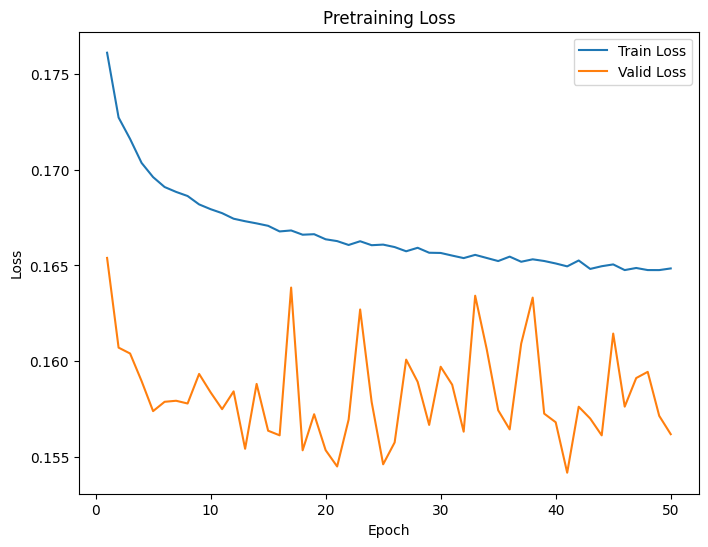

[STraTSExperiment] Pretrain finished.
[STraTSExperiment] Best pretrain model saved at: ./models_pt\pretrained_model_eicu_masked_24_fusion_aki48_8hr.pt


In [8]:
# CLS final_emb
exp_0 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='eicu_masked_24_fusion_aki48_8hr',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

exp_0.load_pretrained_model('./models_pt/pretrained_model_eicu_24h.pt')

# 1) Pretrain
exp_0.pretrain(epochs=50, learning_rate=1e-3)

[STraTSExperiment] Pretrain validation result saved to ./model_results\pretrained_result_eicu_masked_24_fusion_aki48_8hr.csv
[STraTSExperiment] Starting downstream training...


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.2421, Valid Loss=0.2061, Valid AUROC=0.7511, AUPRC=0.1569


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

...

[Downstream] Epoch [96/1000] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Epoch 96] Train Loss=0.1908, Valid Loss=0.1960, Valid AUROC=0.8052, AUPRC=0.2078


[Downstream] Epoch [97/1000] - Training:   0%|          | 0/6111 [00:00<?, ?it/s]

[Downstream] Epoch [97/1000] - Validation:   0%|          | 0/1989 [00:00<?, ?it/s]

[Epoch 97] Train Loss=0.1910, Valid Loss=0.1984, Valid AUROC=0.8061, AUPRC=0.2116
Early stopping triggered (downstream).


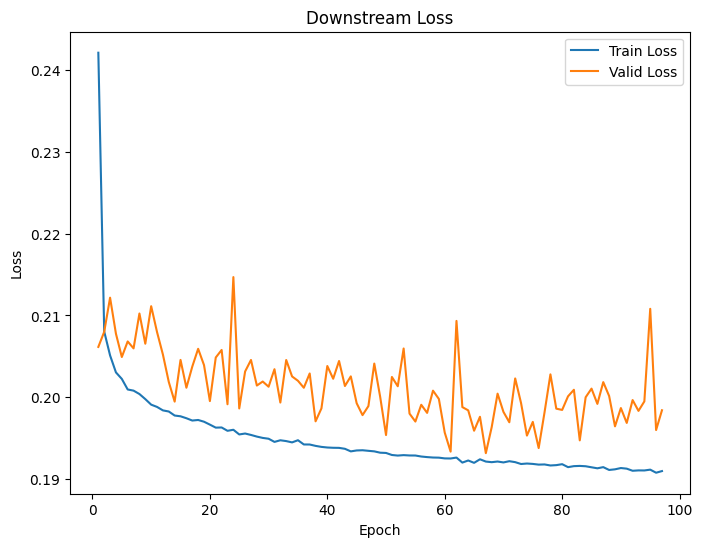

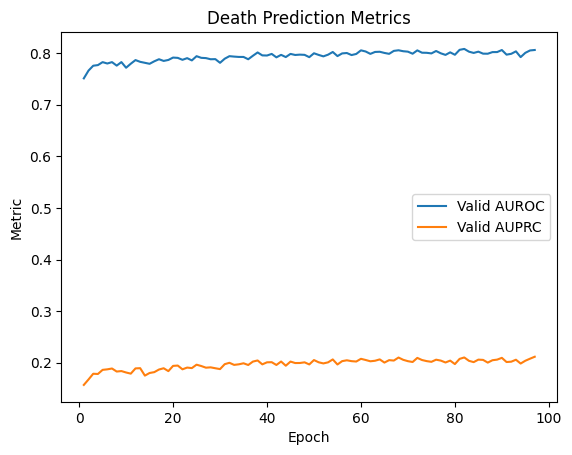

[STraTSExperiment] Downstream training finished.
[STraTSExperiment] Best downstream model saved at: ./models_pt\downstream_model_eicu_masked_24_fusion_aki48_8hr.pt
[STraTSExperiment] Training loss saved to ./model_results\downstream_loss_eicu_masked_24_fusion_aki48_8hr.csv


[Evaluating on dataset]:   0%|          | 0/2046 [00:00<?, ?it/s]

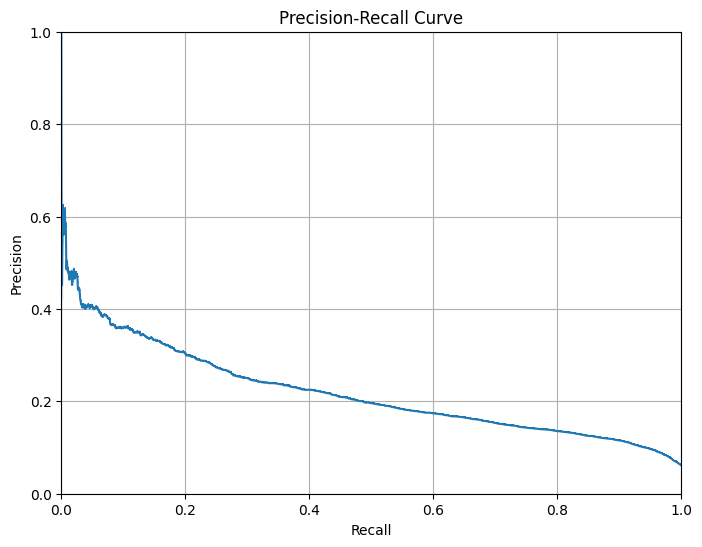

[STraTSExperiment] Test Metrics:
  AUROC: 0.8069
  AUPRC: 0.2189
  Precision: 0.4266
  Recall: 0.0304
  F1: 0.0568
  Accuracy: 0.9381
  Brier: 0.0527
  Precision@Recall_0.8: 0.1358


[Evaluating on dataset]:   0%|          | 0/6111 [00:00<?, ?it/s]

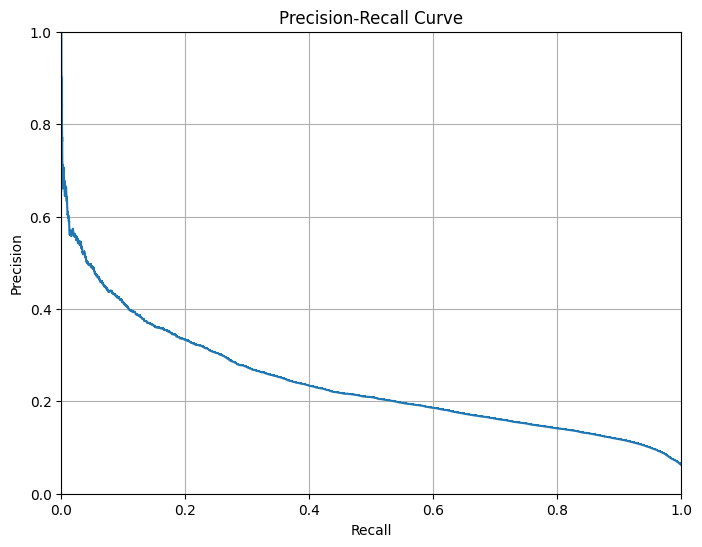

[Evaluating on dataset]:   0%|          | 0/1989 [00:00<?, ?it/s]

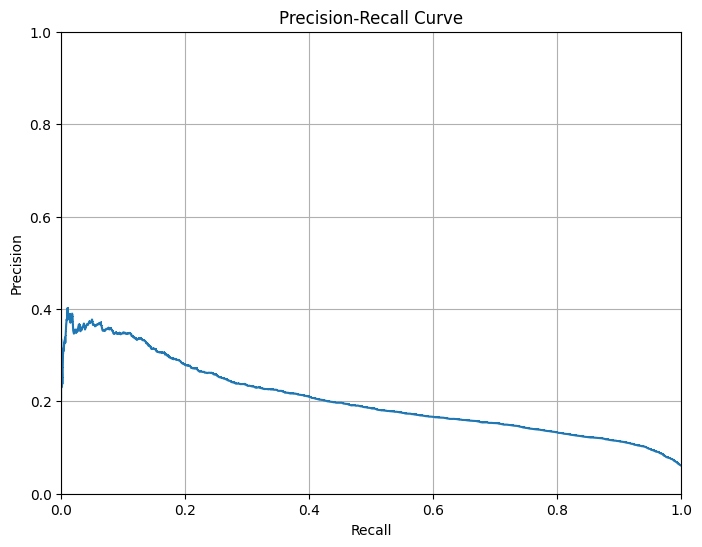

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_eicu_masked_24_fusion_aki48_8hr.csv


In [9]:
# 2) Validate pretrain
exp_0.validate_pretrain()

# 3) Downstream train
exp_0.train_downstream(epochs=1000,
                            freeze=False,
                            learning_rate=1e-4)

# 4) Evaluate
metrics_0 = exp_0.evaluate()

### Task 1

[STraTSExperiment] Initialized with version=eicu_masked_vital_24_fusion_aki48_8hr, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt


[Evaluating on dataset]:   0%|          | 0/1012 [00:00<?, ?it/s]

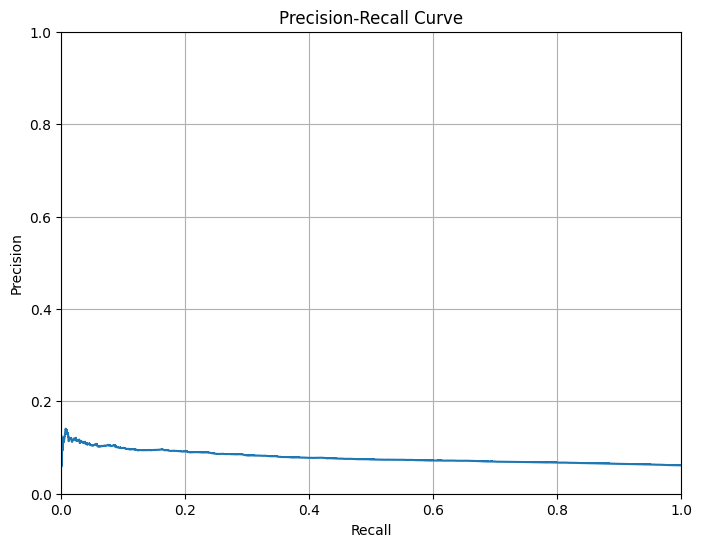

[STraTSExperiment] Test Metrics:
  AUROC: 0.5700
  AUPRC: 0.0790
  Precision: 0.0667
  Recall: 0.0003
  F1: 0.0005
  Accuracy: 0.9384
  Brier: 0.0628
  Precision@Recall_0.8: 0.0674


[Evaluating on dataset]:   0%|          | 0/3024 [00:00<?, ?it/s]

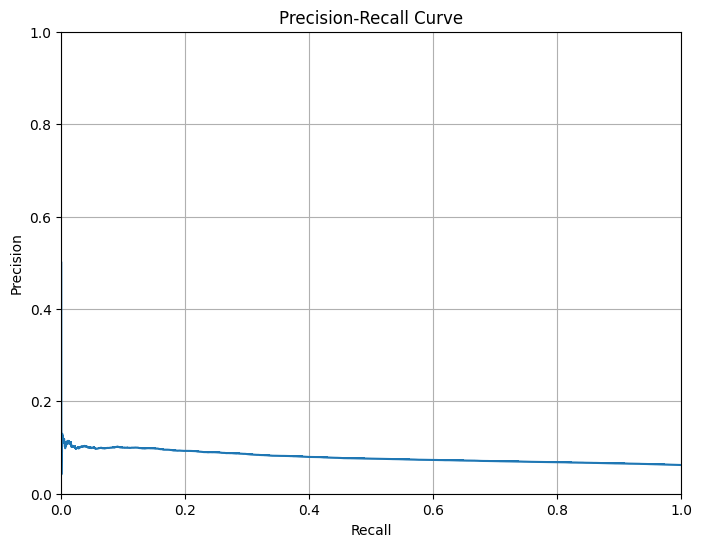

[Evaluating on dataset]:   0%|          | 0/983 [00:00<?, ?it/s]

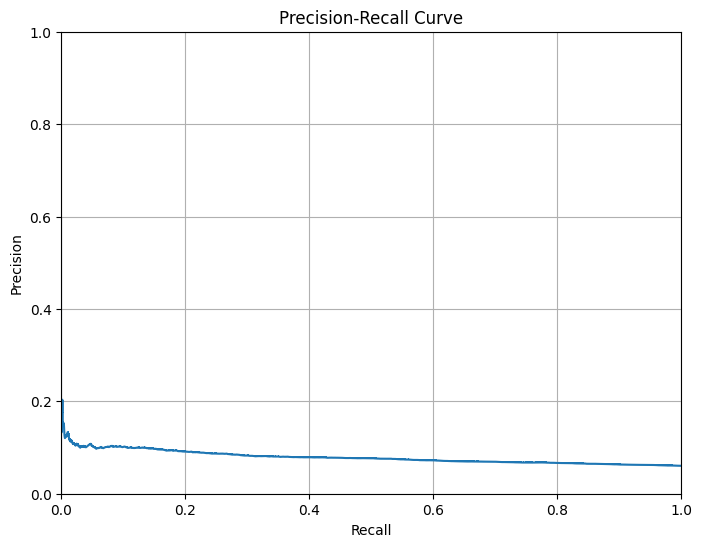

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_eicu_masked_vital_24_fusion_aki48_8hr.csv


In [10]:
# Fusion final_emb
exp_1 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader,
    valid_loader=valid_vital_loader,
    test_loader=test_vital_loader,
    version='eicu_masked_vital_24_fusion_aki48_8hr',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_1.load_downstream_model('./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt')

metrics_1 = exp_1.evaluate()

### Task 2

[STraTSExperiment] Initialized with version=eicu_masked_lab_24_fusion_aki48_8hr, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt


[Evaluating on dataset]:   0%|          | 0/974 [00:00<?, ?it/s]

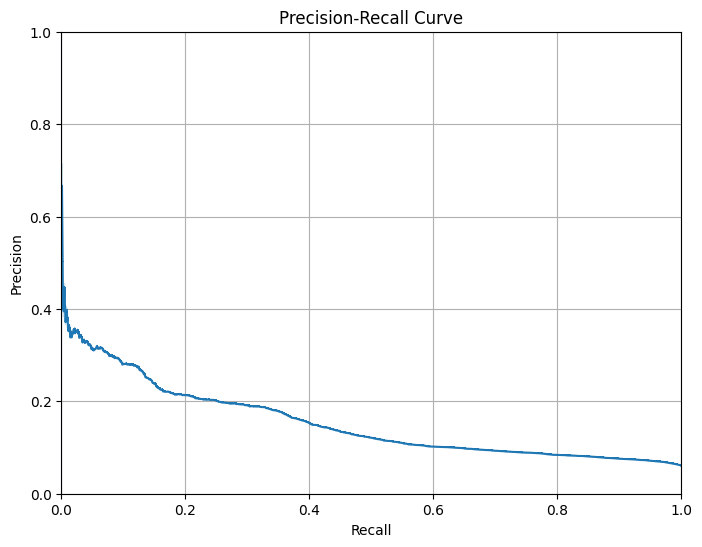

[STraTSExperiment] Test Metrics:
  AUROC: 0.7015
  AUPRC: 0.1537
  Precision: 0.3228
  Recall: 0.0438
  F1: 0.0771
  Accuracy: 0.9370
  Brier: 0.0561
  Precision@Recall_0.8: 0.0840


[Evaluating on dataset]:   0%|          | 0/2887 [00:00<?, ?it/s]

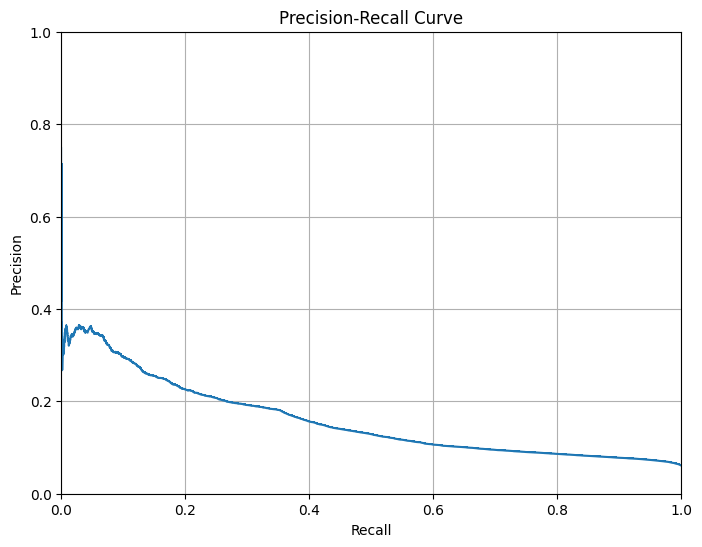

[Evaluating on dataset]:   0%|          | 0/949 [00:00<?, ?it/s]

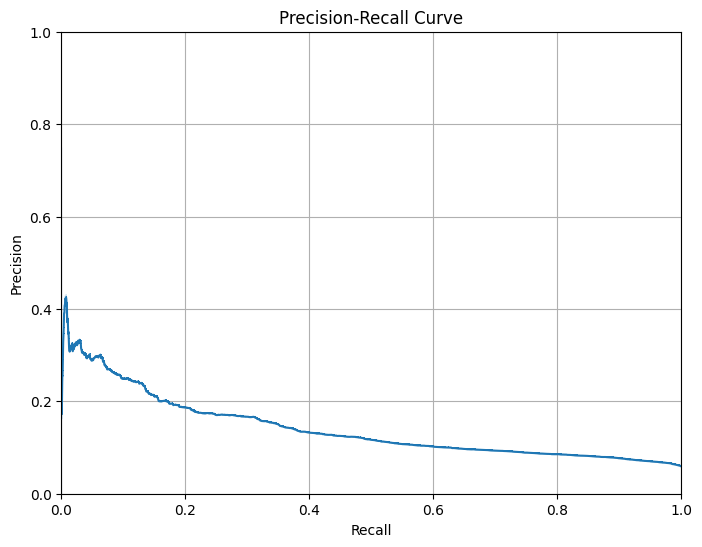

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_eicu_masked_lab_24_fusion_aki48_8hr.csv


In [11]:
# Lab
exp_2 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader,
    valid_loader=valid_lab_loader,
    test_loader=test_lab_loader,
    version='eicu_masked_lab_24_fusion_aki48_8hr',           # None이면 자동으로 날짜_2 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_2.load_downstream_model('./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt')

metrics_2 = exp_2.evaluate()

### Task 3

[STraTSExperiment] Initialized with version=eicu_masked_treatment_24_fusion_aki48_8hr, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt


[Evaluating on dataset]:   0%|          | 0/579 [00:00<?, ?it/s]

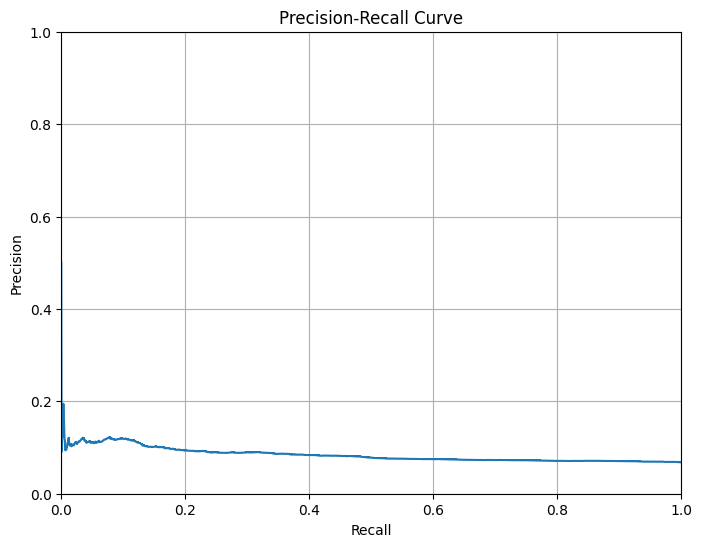

[STraTSExperiment] Test Metrics:
  AUROC: 0.5535
  AUPRC: 0.0843
  Precision: 0.1059
  Recall: 0.0207
  F1: 0.0346
  Accuracy: 0.9217
  Brier: 0.1045
  Precision@Recall_0.8: 0.0714


[Evaluating on dataset]:   0%|          | 0/1742 [00:00<?, ?it/s]

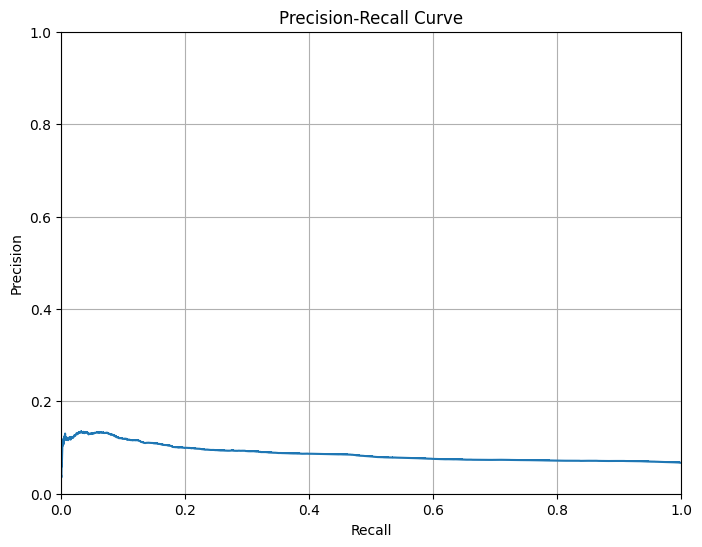

[Evaluating on dataset]:   0%|          | 0/563 [00:00<?, ?it/s]

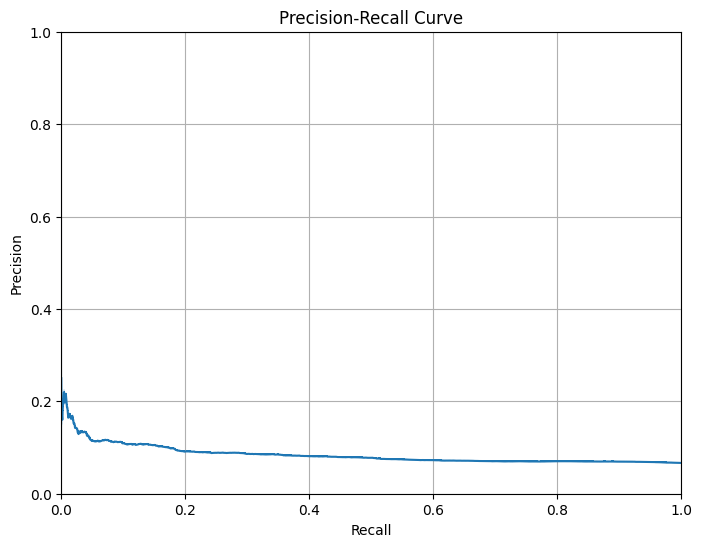

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_eicu_masked_treatment_24_fusion_aki48_8hr.csv


In [12]:
# treatment
exp_3 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader,
    valid_loader=valid_treatment_loader,
    test_loader=test_treatment_loader,
    version='eicu_masked_treatment_24_fusion_aki48_8hr',           # None이면 자동으로 날짜_3 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

# 1) Pretrain
exp_3.load_downstream_model('./models_pt/downstream_model_eicu_masked_24_fusion_aki48_8hr.pt')

metrics_3 = exp_3.evaluate()